# Introduction #

This report explores K-Means clustering, an unsupervised machine learning method used to uncover patterns in unlabeled data. [<sup>1</sup>](#fn1). It groups similar observations based on their distance to cluster centroids.[<sup>2</sup>](#fn2). 

Distance between data points is measured relative to cluster centroids, which serve as the centers of each cluster and are initialized before clustering begins. K-Means clustering has many business applications, including customer segmentation, where it is used to identify patterns in customer behavior and inform marketing strategies that can provide a competitive advantage.[<sup>3</sup>](#fn3)

This analysis applies K-Means clustering to segment customer credit card usage behavior. The data is first scaled to ensure all variables contribute equally to the clustering process, reducing bias from differing feature magnitudes. Principal Component Analysis (PCA) is then used to reduce dimensionality and remove noise while preserving key structure in the data. These steps improve clustering performance and enable clearer identification of patterns in customer behavior using a public dataset.



# Data #

The dataset, “Credit Card Dataset for Clustering,” is sourced from Kaggle and contains 8,950 credit card usage profiles. This dataset can be used for customer segmentation by grouping individuals with similar purchasing and financial behavior patterns using clustering methods. 

There are 18 variables in this data set representing a characteristic for each . The data set contains categorical, continuous, and ordinal variables. The categorical variables are objects and the continuous variables and ordinal variables are integers and floats. Explanations of each data attribute is shown below[<sup>4</sup>](#fn4):


1.) **CUST_ID** : Identification of Credit Card Holder 

(Categorical Variable)

2.) **BALANCE** : Balance amount left in their account to make purchases 

(Continuous Variable)

3.) **BALANCE_FREQUENCY** : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)  

(Ordinal Variable)

4.) **PURCHASES** : Amount of purchases made from account 

(Continuous Variable)

5.) **ONEOFF_PURCHASES** : Maximum purchase amount done in one-go

(Continuous Variable)

6.) **INSTALLMENTS_PURCHASES** : Amount of purchase done in installment 

(Continuous Variable)

7.) **CASH_ADVANCE** : Cash in advance given by the user 

(Continuous Variable)

8.) **PURCHASES_FREQUENCY** : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)  

(Ordinal Variable)

9.) **ONEOFF_PURCHASES_FREQUENCY** : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)  

(Ordinal Variable)

10.) **PURCHASES_INSTALLMENTS_FREQUENCY** : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)  

(Ordinal Variable)

11.) **CASH_ADVANCE_FREQUENCY** : How frequently the cash in advance being paid  

(Ordinal Variable)

12.) **CASH_ADVANCE_TRX** : Number of Transactions made with "Cash in Advanced" 

(Continuous Variable)

13.) **PURCHASES_TRX** : Number of purchase transactions made 

(Continuous Variable)

14.) **CREDIT_LIMIT** : Limit of Credit Card for user 

(Continuous Variable)

15.) **PAYMENTS** : Amount of Payment done by user 

(Continuous Variable)

16.) **MINIMUM_PAYMENTS** : Minimum amount of payments made byuser 

(Continuous Variable)

17.) **PRC_FULL_PAYMENT** : Percent of full payment paid by user 

(Continuous Variable)

18.) **TENURE** : Tenure of credit card service for user 


(Continuous Variable)

# Methodology #

The analysis begins by importing key Python libraries for data processing, visualization, and clustering, including Pandas, NumPy, Matplotlib, PowerTransformer, MinMaxScaler, KMeans, PCA, and evaluation tools such as the Elbow and Silhouette visualizers.

The dataset is then loaded into a dataframe, where data types are inspected and missing values are identified. A total of 313 missing values were found in the “MISSING_PAYMENTS” variable.

Because K-Means clustering cannot be applied directly to data containing missing values, the missing observations were examined before proceeding with the analysis. An exploratory review suggested that the missing values in the "MINIMUM_PAYMENTS" variable were related to the values in "PAYMENTS" rather than occurring completely at random. For many records with missing minimum payment values, the corresponding payment amount was zero. Based on the context of the dataset, these missing values were assumed to represent either customers with no minimum payment obligation or customers who made no payments during the period. Therefore, the missing values were imputed with 0 to allow the clustering analysis to proceed while maintaining a reasonable interpretation of the underlying customer behavior.

After addressing the missing values, the data was prepared for K-Means clustering. Because K-Means is sensitive to differences in feature scales, the variables were evaluated and transformed to ensure that no single feature disproportionately influenced the clustering results. To determine an appropriate preprocessing approach, the distributions of the variables were examined to assess normality, and a correlation analysis was conducted to identify highly correlated features.


Inspection of the variable distributions revealed that many features were highly skewed and deviated from normality. Because clustering algorithms are sensitive to differences in feature scales and the presence of outliers, a Power Transformation was applied to reduce skewness and stabilize the distributions. The transformed features were then scaled to a 0–1 range to ensure that all variables contributed more equally to the clustering process.

To assess multicollinearity, I generated a correlation matrix for all variables and identified several features with strong positive correlations. Because highly correlated variables can introduce redundancy and influence clustering results, this analysis informed the subsequent use of PCA for dimensionality reduction.

After transforming and scaling the data, I applied Principal Component Analysis (PCA) to reduce dimensionality and visualize the dataset into two principal components for visualization. PCA helped capture the most important patterns in the data while reducing redundancy from highly correlated features, making it easier to evaluate and interpret customer segments.

To determine the optimal number of clusters, I evaluated K-Means models using the elbow method, silhouette scores, and inertia values across multiple cluster configurations. By comparing these metrics and visualizing the resulting clusters, I selected the most appropriate segmentation and analyzed customer behavior patterns within each group.

# Analysis #

In [1]:
# for importing csv file
import pandas as pd
import numpy as np
import sklearn

# for transforming and scaling data
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler

# for reducing dimensions 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# for finding optimal K-Means Clusters and Silhouette Score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import adjusted_rand_score

# for plotting results
import matplotlib.pyplot as plt
from matplotlib import pyplot
import seaborn

/var/folders/hz/g9cqmq7n0wn6mfbwwpbktlnr0000gn/T/ipykernel_56365/1278289984.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# upload data
data = pd.read_csv("CC GENERAL.csv")
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# check data type of variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
# check for missing values in data
data.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [5]:
# replace missing values with 0 in data
data.fillna(0, inplace = True)

In [6]:
# check for duplicates in data
data.duplicated().sum()

0

In [7]:
# descriptive statistics of the data before transforming and scaling
data.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.0,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.0,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.0,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.0,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.0,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.0,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.0,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.0,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.0,0.000000,0.000000,0.222222,1.50000


In [8]:
# checking correlation of variables
correlation_matrix = data.corr(numeric_only=True)
correlation_matrix.style.background_gradient()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531324,0.322802,0.399642,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.096200,0.065008,0.140632,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356993,0.603264,0.096993,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319743,0.567292,0.051151,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256537,0.384084,0.135223,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.304009,0.453238,0.141491,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119937,0.103464,0.007943,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295099,0.243537,-0.025791,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060874,0.085551,0.033421,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132583,0.183192,0.102067,-0.249773,-0.133372


array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

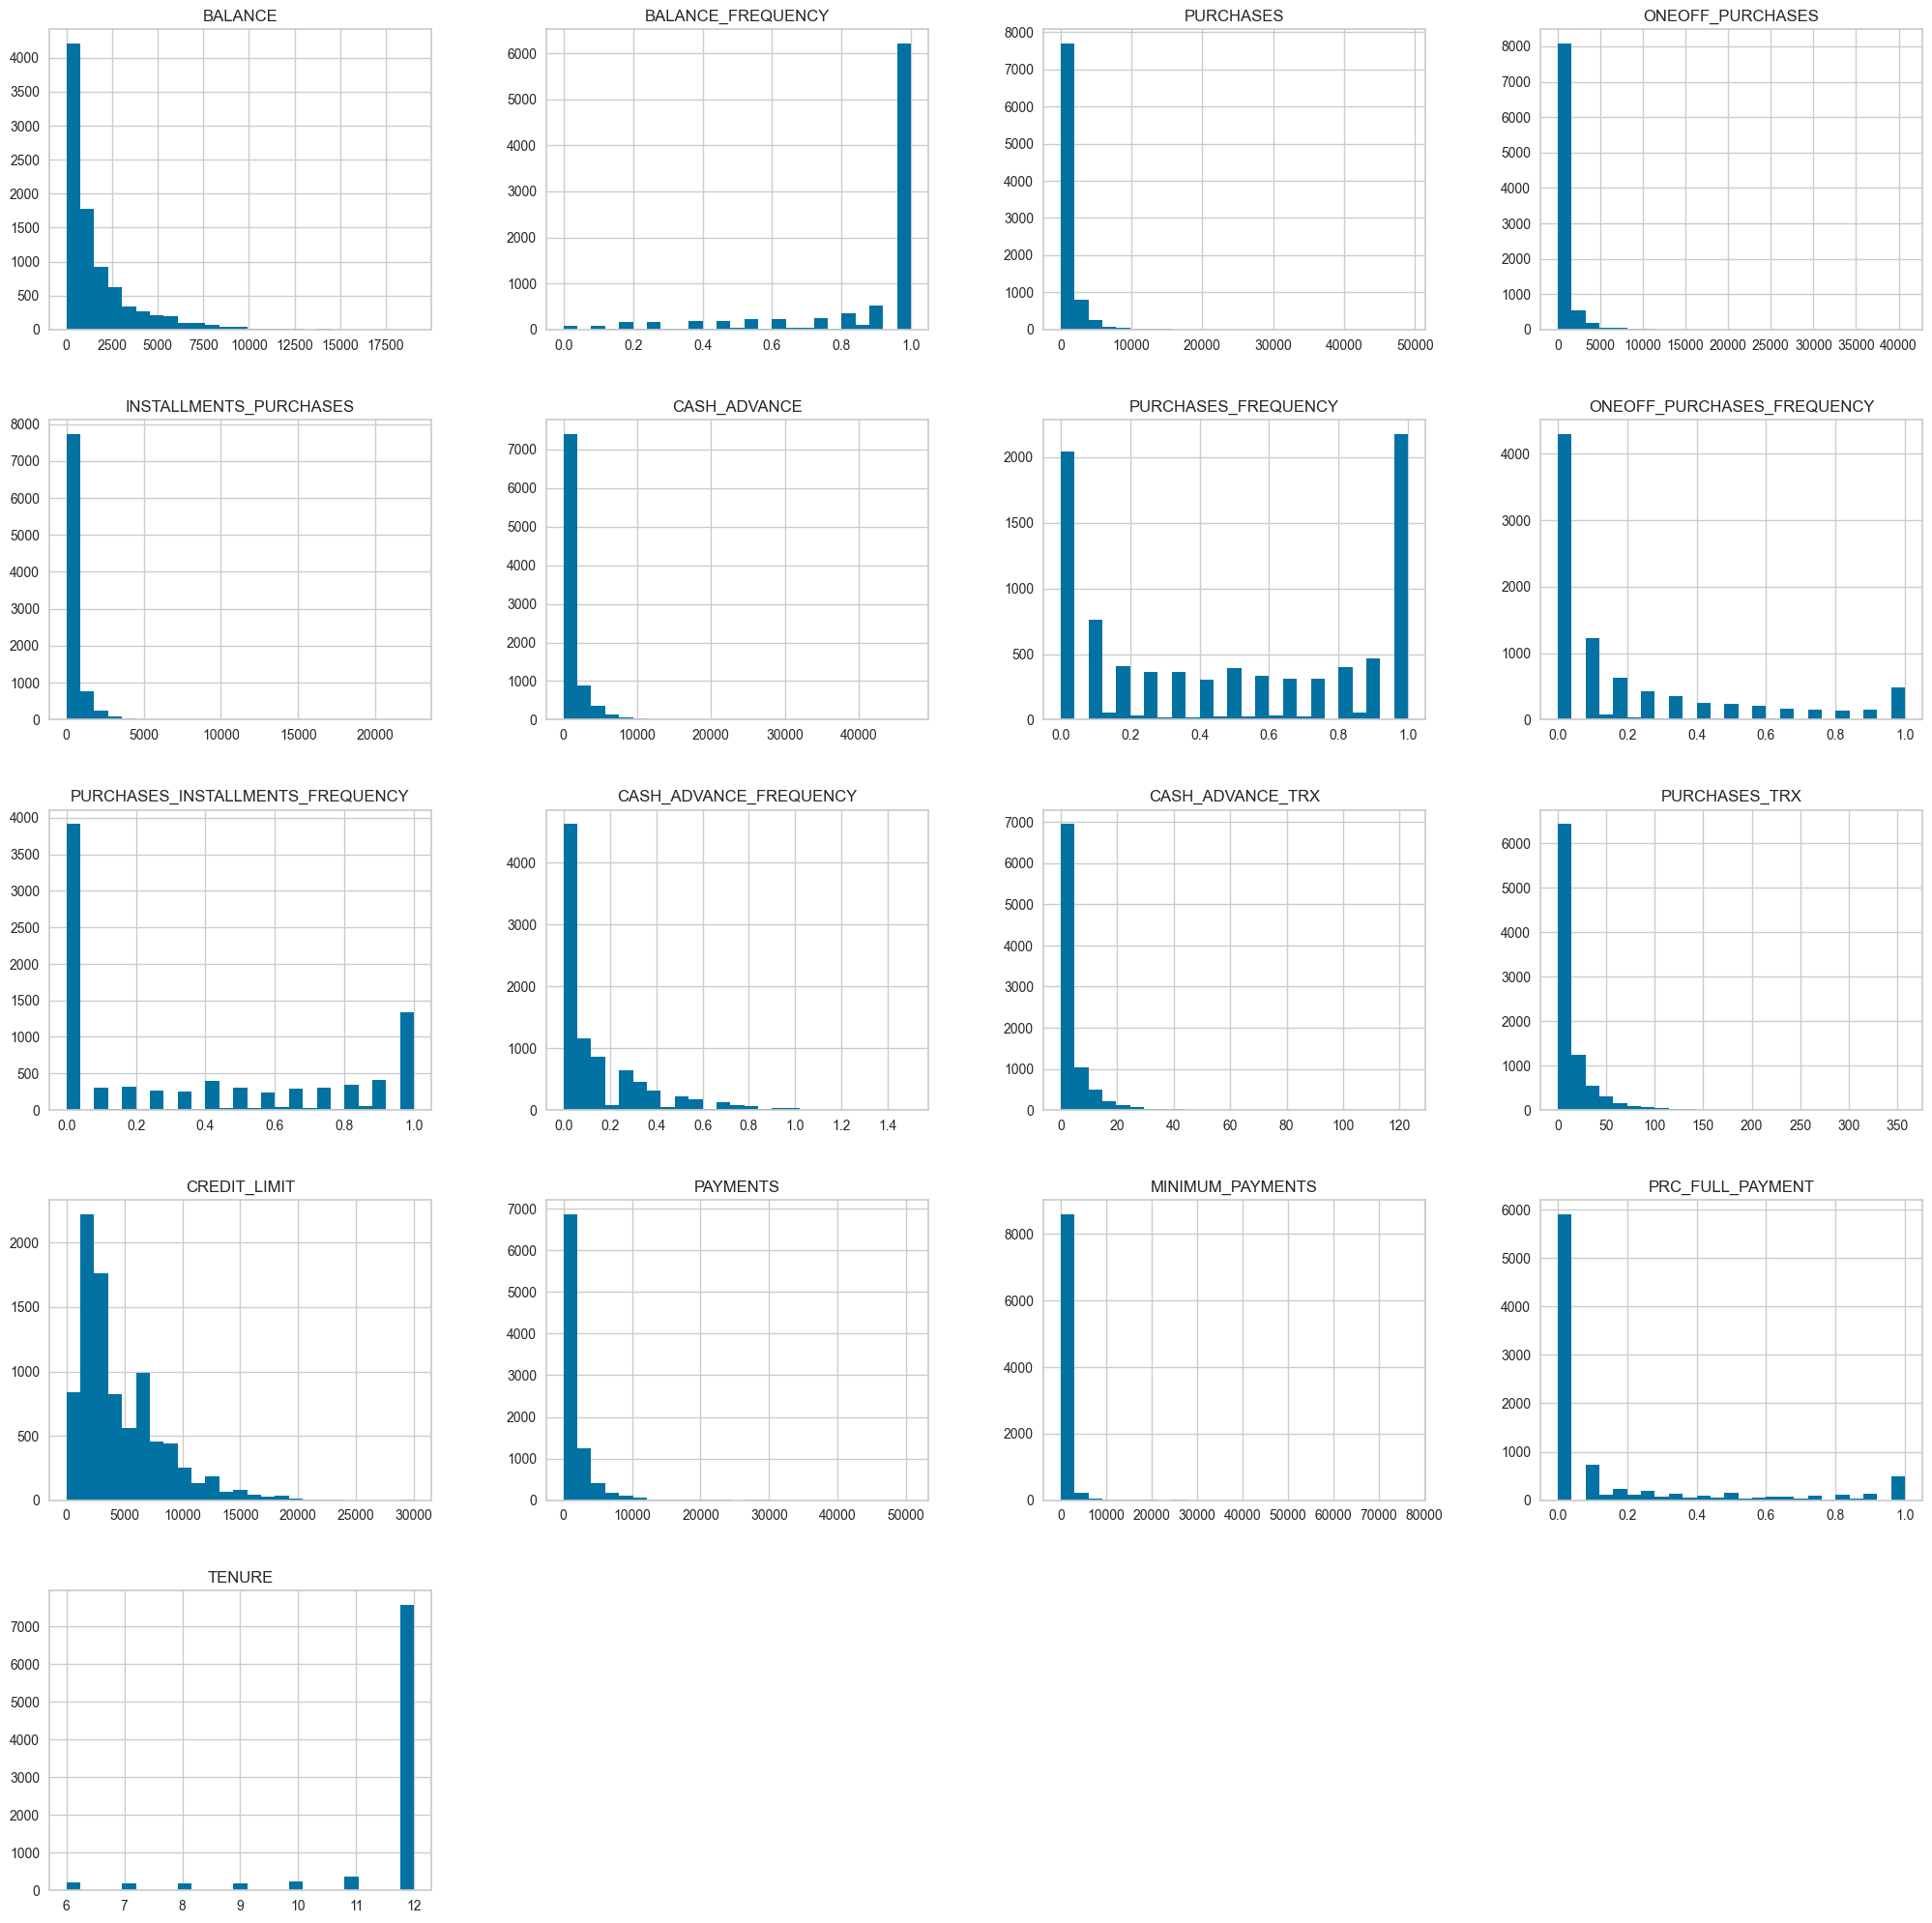

In [9]:
# create histograms of data to check if they have a normal distrubtion
data.hist(bins=25, figsize=(25,25))

In [10]:
# new dataframe to apply transformation and scaling on
data2 = data.copy()
# dropping categorical variable
data2 = data2.drop("CUST_ID", axis = 1)
data2

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,0.000000,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [11]:
# transforming data
# foot note 5
power = PowerTransformer(method='yeo-johnson', standardize=True)
newdata = power.fit_transform(data2)
# scaling data
scaled_data = MinMaxScaler().fit_transform(newdata)

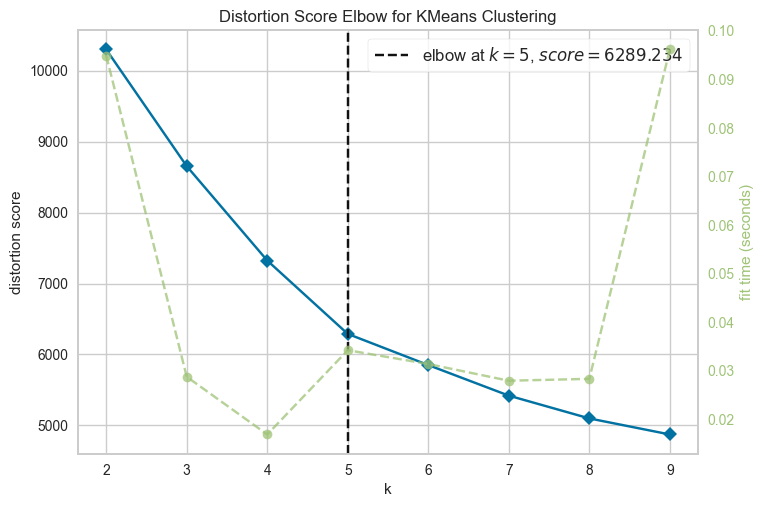

Best number of clusters: 5
Elbow-selected number of clusters: 6289.234195131574


In [12]:
# applying elbow method
# foot note 6
model = KMeans()
elbow = KElbowVisualizer(model, k=(2,10))
                      
elbow.fit(scaled_data)
elbow.show()
print("Best number of clusters:", elbow.elbow_value_)
print("Elbow-selected number of clusters:", elbow.elbow_score_)

In [13]:
# using PCA to reduce data into lower dimensions
pca2 = PCA(2)
pca2_data = pca2.fit_transform(scaled_data)

In [14]:
# applying K-Means algorithm with 3 clusters
# footnote 7
kmeans3 = KMeans(n_clusters = 3, init = "k-means++")
label3 = kmeans3.fit_predict(pca2_data)
cluster3 = np.array(kmeans3.cluster_centers_)

In [15]:
# calculating silhouette score of 3 clusters
score3 = silhouette_score(pca2_data, kmeans3.labels_, metric='euclidean')
print('Silhouette Score:', score3)

Silhouette Score: 0.45013739228554417


In [16]:
# applying K-Means algorithm with 4 clusters
# footnote 8
kmeans4 = KMeans(n_clusters = 4, init = "k-means++")
label4 = kmeans4.fit_predict(pca2_data)
cluster4 = np.array(kmeans4.cluster_centers_)

In [17]:
# calculating silhouette score of 4 clusters
score4 = silhouette_score(pca2_data, kmeans4.labels_, metric='euclidean')
print('Silhouette Score:', score4)

Silhouette Score: 0.47201496980938734


In [18]:
# applying K-Means algorithm with 5 clusters
# footnote 9
kmeans5 = KMeans(n_clusters = 5, init = "k-means++")
label5 = kmeans5.fit_predict(pca2_data)
cluster5 = np.array(kmeans5.cluster_centers_)

In [19]:
# calculating silhouette score of 5 clusters
score5 = silhouette_score(pca2_data, kmeans5.labels_, metric='euclidean')
print('Silhouette Score:', score5)

Silhouette Score: 0.4475292250435235


In [20]:
# applying K-Means algorithm with 6 clusters
# footnote 10
kmeans6 = KMeans(n_clusters = 6, init = "k-means++")
label6 = kmeans6.fit_predict(pca2_data)
cluster6 = np.array(kmeans6.cluster_centers_)

In [21]:
# calculating silhouette score of 6 clusters
score6 = silhouette_score(pca2_data, kmeans6.labels_, metric='euclidean')
print('Silhouette Score:', score6)

Silhouette Score: 0.4516064052138759


In [22]:
# applying K-Means algorithm with 7 clusters
# footnote 11
kmeans7 = KMeans(n_clusters = 7, init = "k-means++")
label7 = kmeans7.fit_predict(pca2_data)
cluster7 = np.array(kmeans7.cluster_centers_)

In [23]:
# calculating silhouette score of 7 clusters
score7 = silhouette_score(pca2_data, kmeans7.labels_, metric='euclidean')
print('Silhouette Score:', score7)

Silhouette Score: 0.42752085429460446


In [24]:
# applying K-Means algorithm with 8 clusters
# footnote 12
kmeans8 = KMeans(n_clusters = 8, init = "k-means++")
label8 = kmeans8.fit_predict(pca2_data)
cluster8 = np.array(kmeans8.cluster_centers_)


In [25]:
# calculating silhouette score of 8 clusters
score8 = silhouette_score(pca2_data, kmeans8.labels_, metric='euclidean')
print('Silhouette Score:', score8)

Silhouette Score: 0.3862023216249049


In [26]:
# comparing results of each different number k clusters
print("The score of 3 clusters:", score3)
print("The score of 4 clusters:", score4)
print("The score of 5 clusters:", score5)
print("The score of 6 clusters:", score6)
print("The score of 7 clusters:", score7)
print("The score of 8 clusters:", score8)

The score of 3 clusters: 0.45013739228554417
The score of 4 clusters: 0.47201496980938734
The score of 5 clusters: 0.4475292250435235
The score of 6 clusters: 0.4516064052138759
The score of 7 clusters: 0.42752085429460446
The score of 8 clusters: 0.3862023216249049


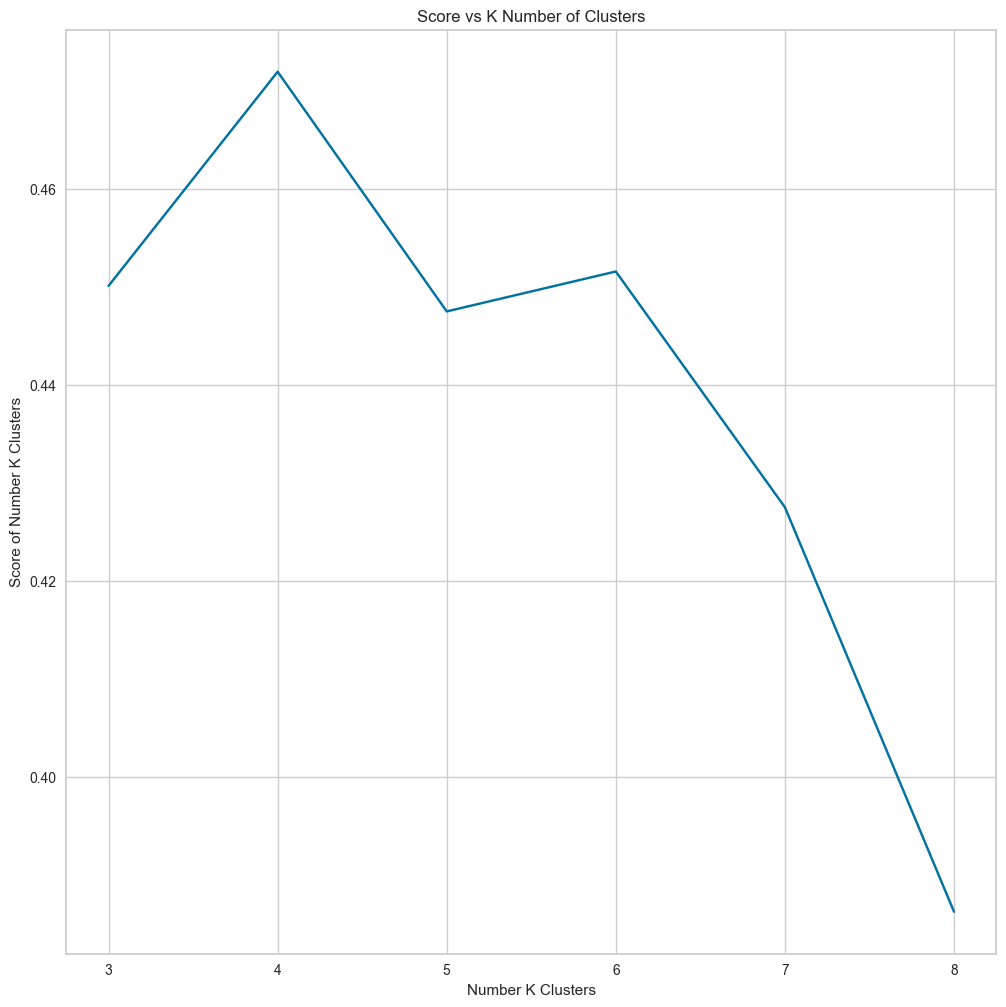

In [27]:
plt.figure(figsize=(12,12))
k = [3,4,5,6,7,8]
scores = [score3, score4, score5, score6, score7, score8]
plt.title("Score vs K Number of Clusters")
plt.xlabel("Number K Clusters")
plt.ylabel("Score of Number K Clusters")

plt.plot(k, scores)
plt.show()

In [28]:
# comparing results of each different number k clusters
print("The inertia of 3 clusters:", kmeans3.inertia_)
print("The inertia of 4 clusters:", kmeans4.inertia_)
print("The inertia of 5 clusters:", kmeans5.inertia_)
print("The inertia of 6 clusters:", kmeans6.inertia_)
print("The inertia of 7 clusters:", kmeans7.inertia_)
print("The inertia of 8 clusters:", kmeans8.inertia_)

The inertia of 3 clusters: 2693.4191567241232
The inertia of 4 clusters: 1753.5870718897359
The inertia of 5 clusters: 1439.9230793434276
The inertia of 6 clusters: 1241.6128781206505
The inertia of 7 clusters: 1023.7478240778164
The inertia of 8 clusters: 929.8056878806258


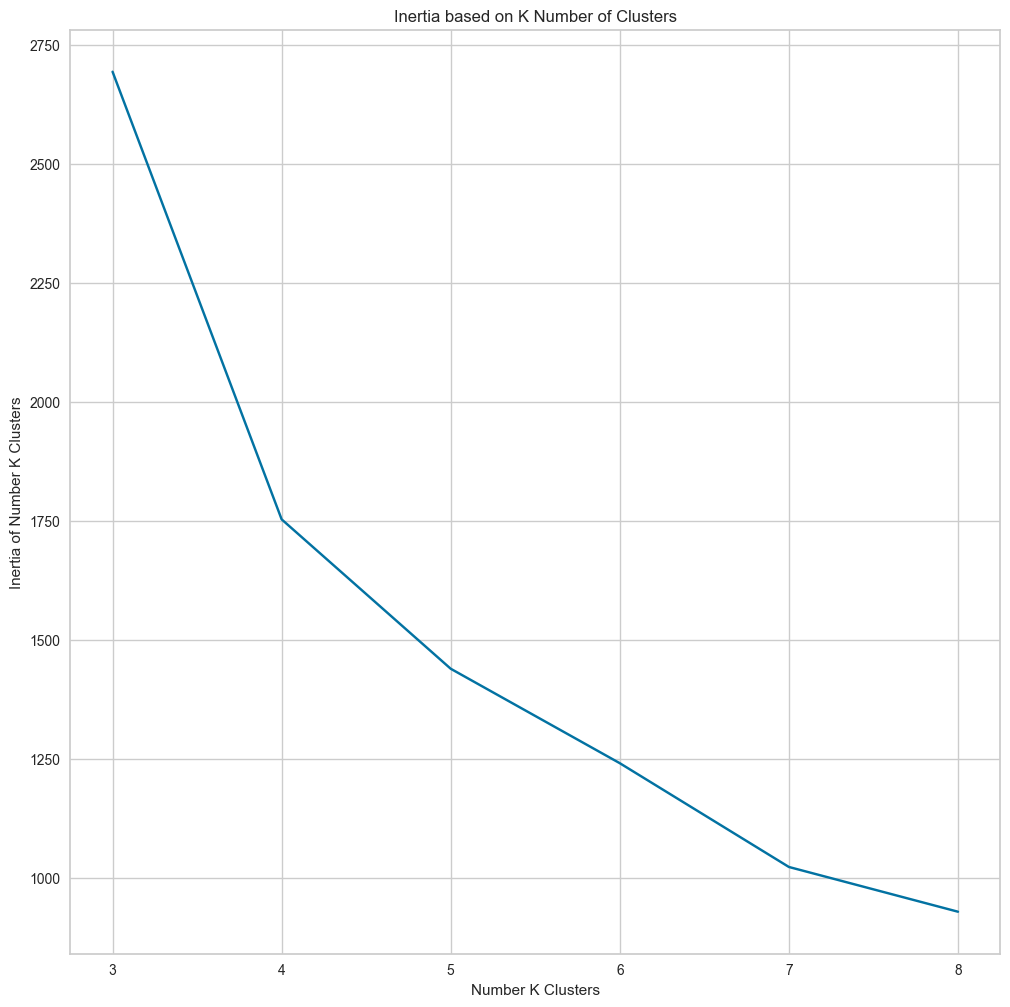

In [29]:
# graphing the inertia based on k-clusters
plt.figure(figsize=(12,12))
k = [3,4,5,6,7,8]
inertia = [kmeans3.inertia_, kmeans4.inertia_, kmeans5.inertia_, kmeans6.inertia_, kmeans7.inertia_, kmeans8.inertia_]
plt.title("Inertia based on K Number of Clusters")
plt.xlabel("Number K Clusters")
plt.ylabel("Inertia of Number K Clusters")

plt.plot(k, inertia)
plt.show()

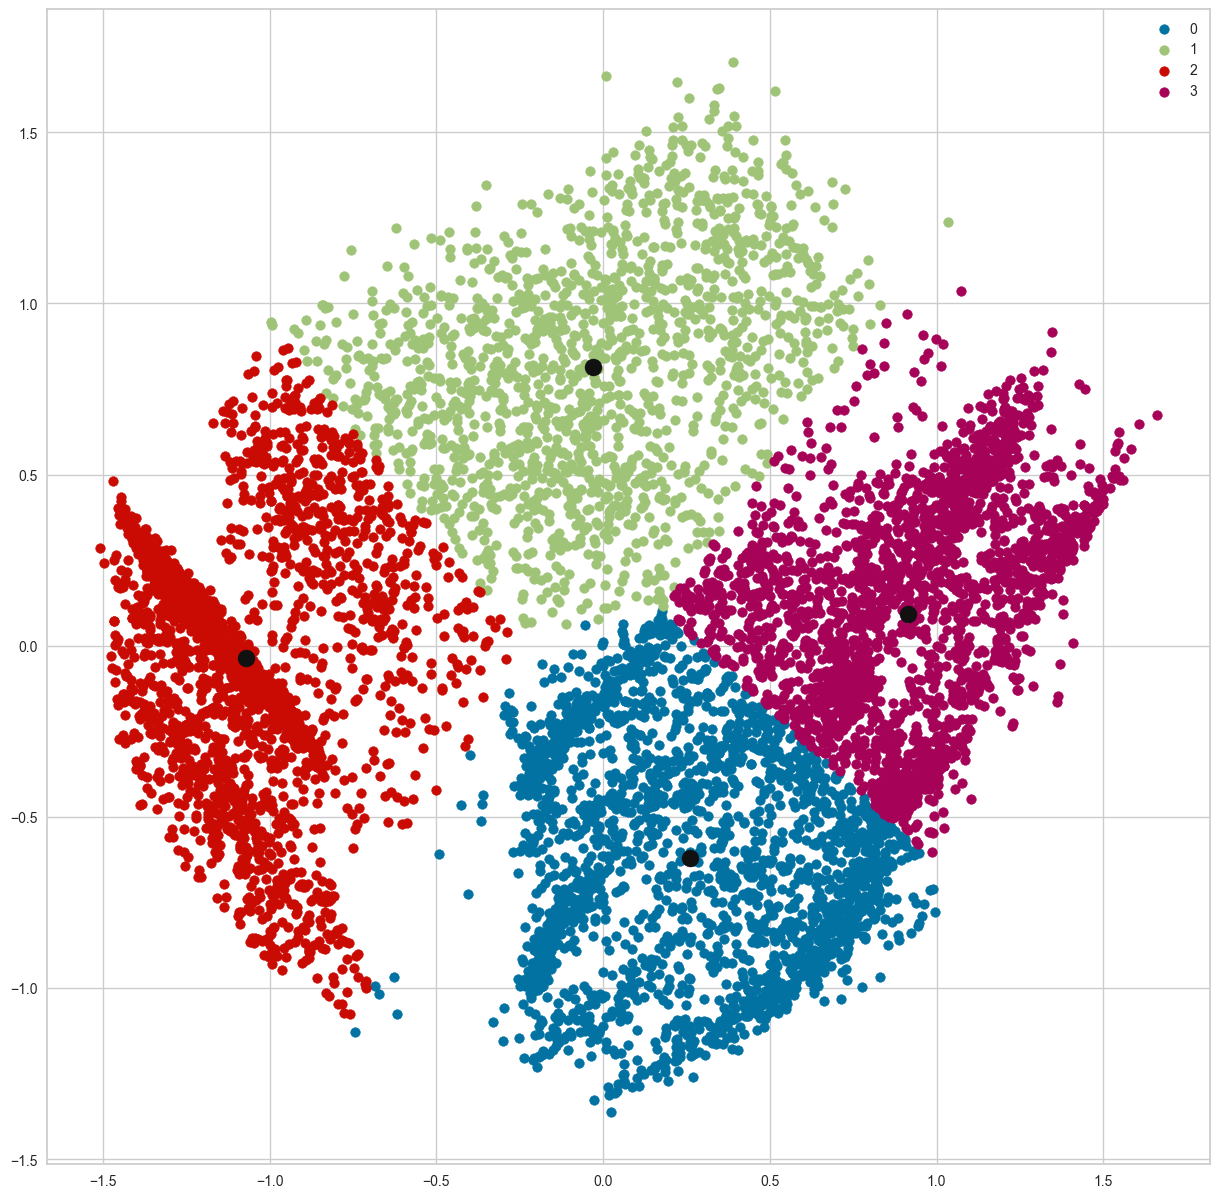

In [30]:
# plotting 4 clusters 
plt.figure(figsize=(15,15))
values4 = np.unique(label4)
for i in values4:
  plt.scatter(pca2_data[label4 == i , 0] , pca2_data[label4 == i , 1] , label = i)

plt.scatter(cluster4[:,0], cluster4[:,1], marker="o", color='k', s=150)
plt.legend()
plt.show()

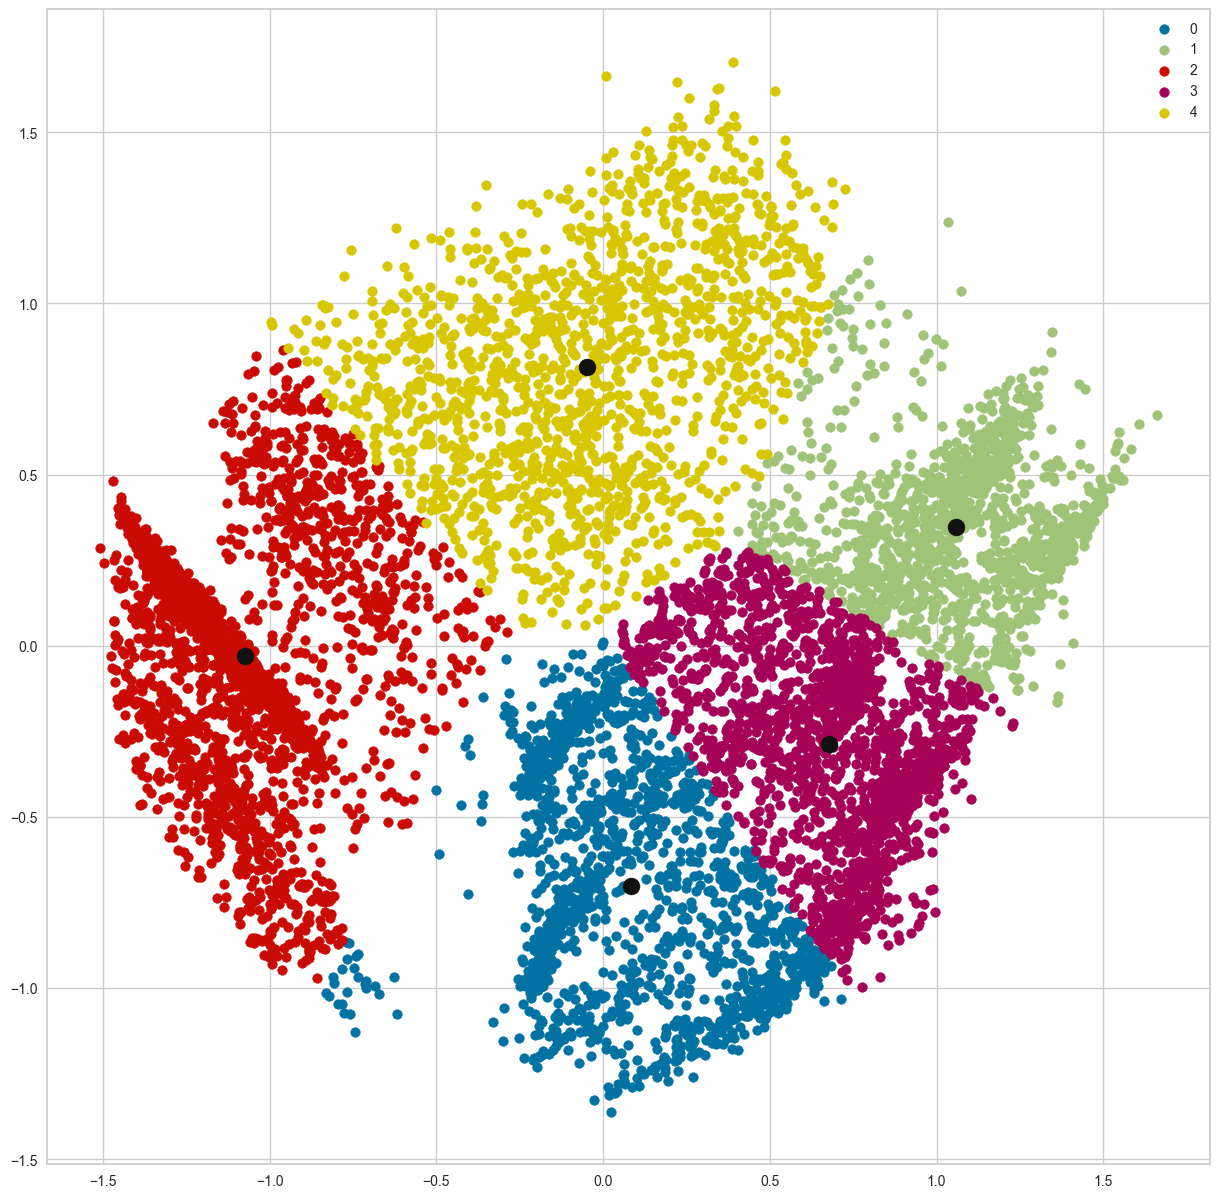

In [31]:
# plotting 5 clusters
plt.figure(figsize=(15,15))
values5 = np.unique(label5)
for i in values5:
  plt.scatter(pca2_data[label5 == i , 0] , pca2_data[label5 == i , 1] , label = i)

plt.scatter(cluster5[:,0], cluster5[:,1], marker="o", color='k', s=150)
plt.legend()
plt.show()

In [32]:
# create new column for clusters using k = 5 clusters
data2["5clusters"] = kmeans5.labels_
# new dataframe with clusters
data2

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,5clusters
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,3
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,0.000000,0.000000,6,3
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,0
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,2


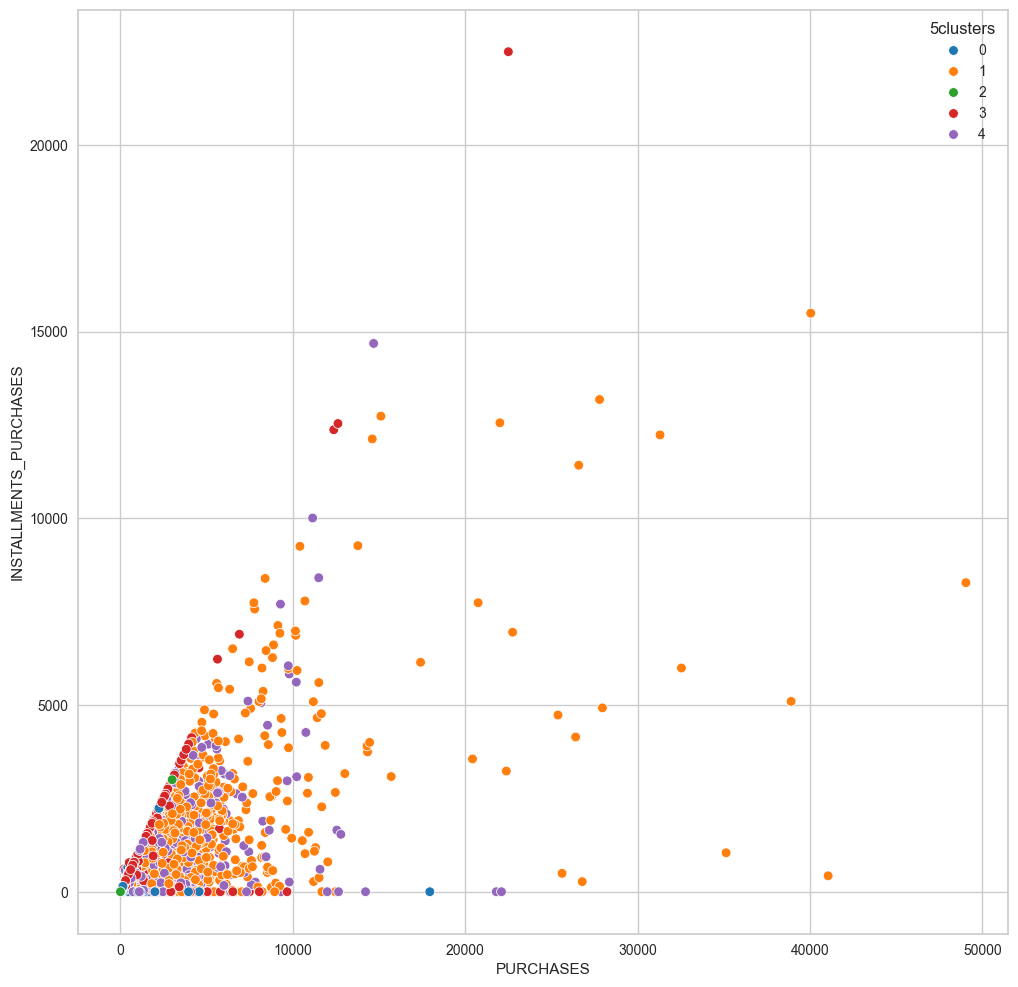

In [33]:
# 5 clusters
plt.figure(figsize=(12,12))
seaborn.scatterplot(data= data2, x=('PURCHASES'),y=('INSTALLMENTS_PURCHASES'), hue='5clusters',palette='tab10')
plt.show()

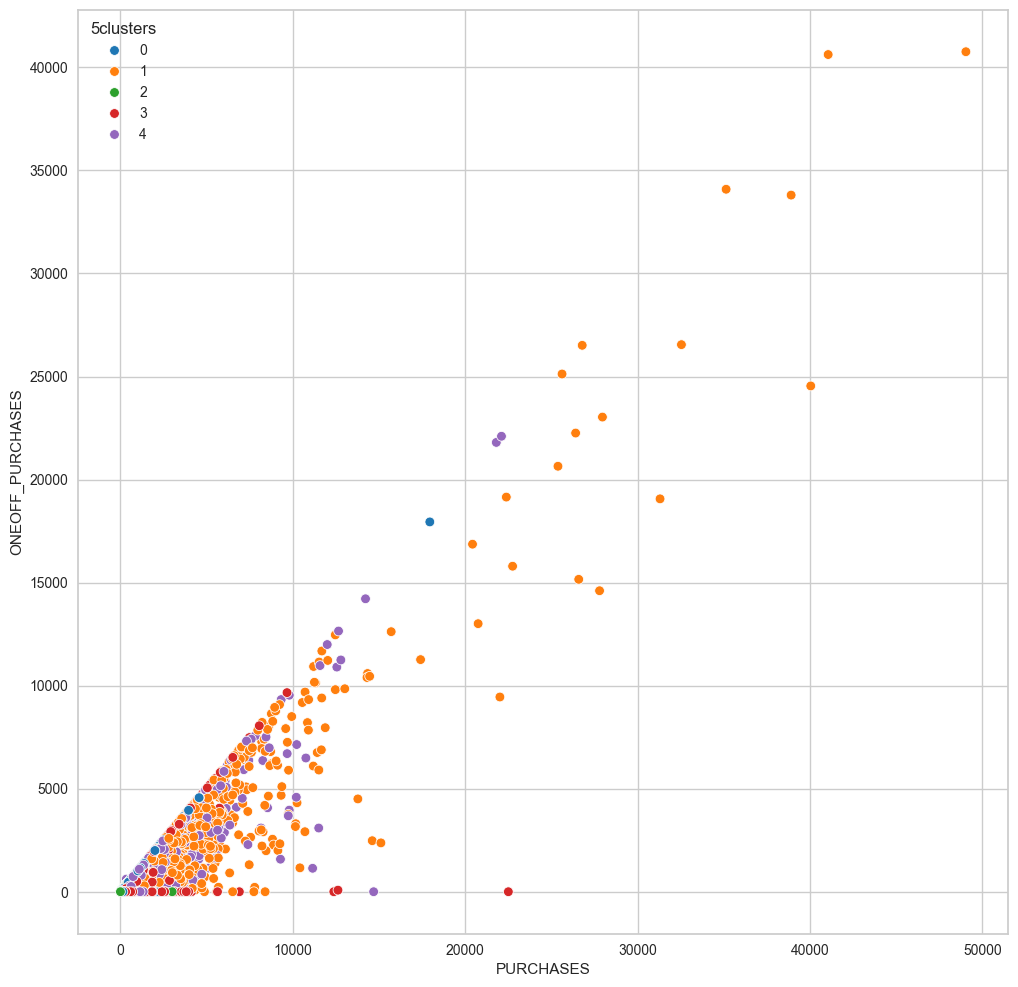

In [34]:
# 5 clusters
plt.figure(figsize=(12,12))
seaborn.scatterplot(data= data2, x=('PURCHASES'),y=('ONEOFF_PURCHASES'), hue='5clusters', palette='tab10')
plt.show()

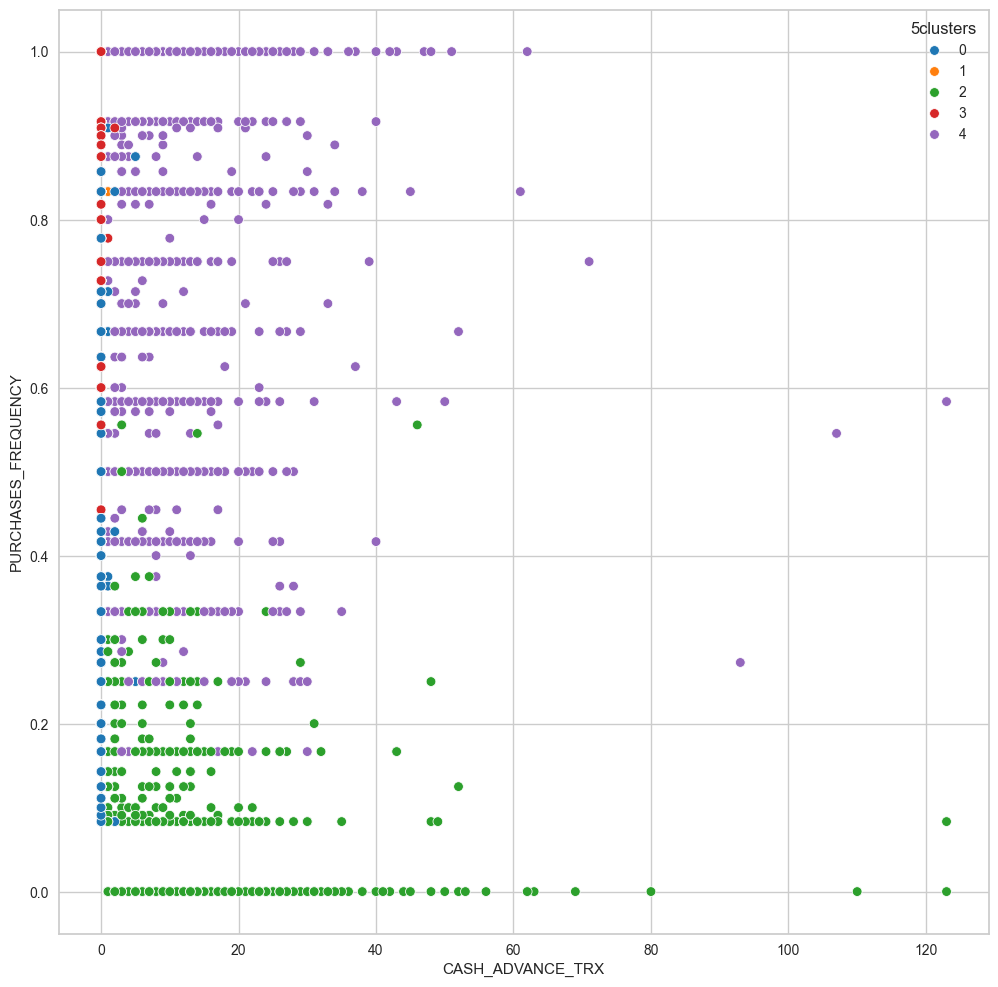

In [35]:
# 5 clusters
plt.figure(figsize=(12,12))
seaborn.scatterplot(data= data2, x=('CASH_ADVANCE_TRX'),y=('PURCHASES_FREQUENCY'), hue='5clusters',palette='tab10')
plt.show()

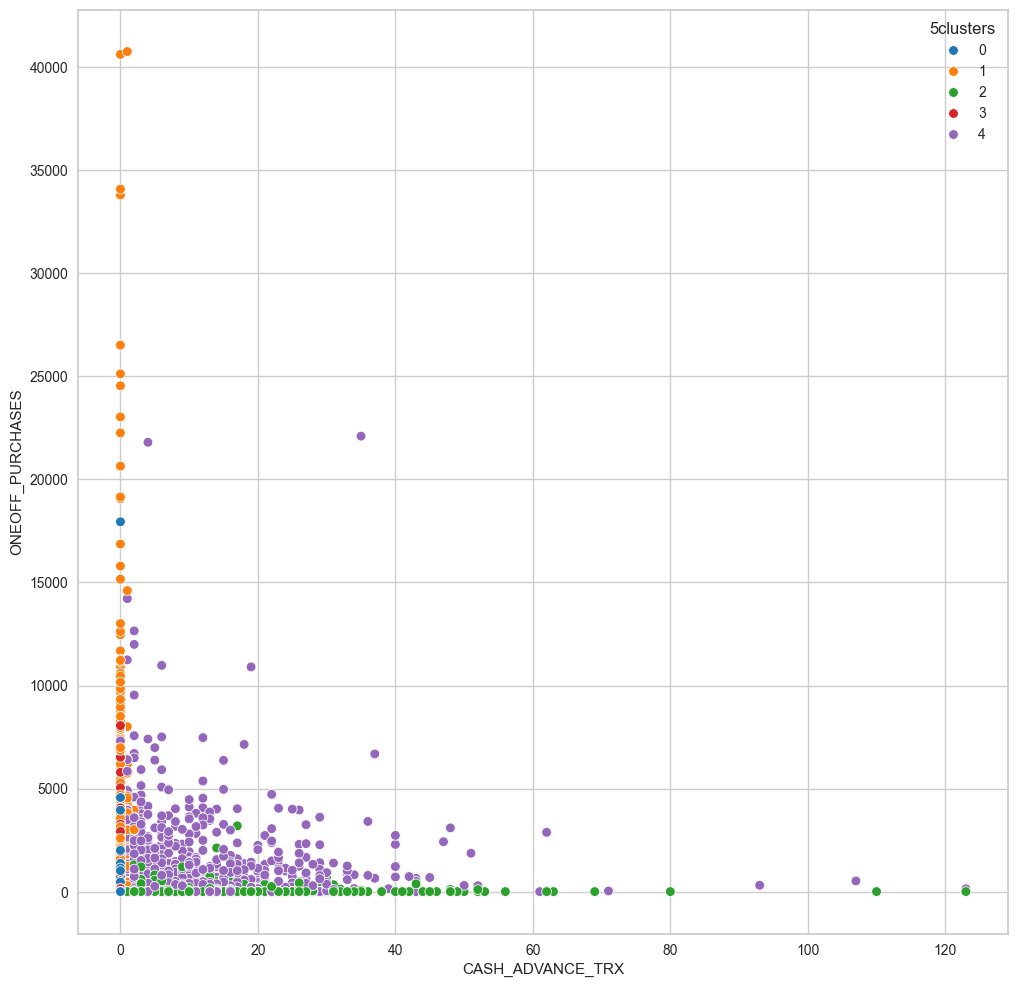

In [36]:
# 5 clusters
plt.figure(figsize=(12,12))
seaborn.scatterplot(data= data2, x=('CASH_ADVANCE_TRX'),y=('ONEOFF_PURCHASES'), hue='5clusters',palette='tab10')
plt.show()

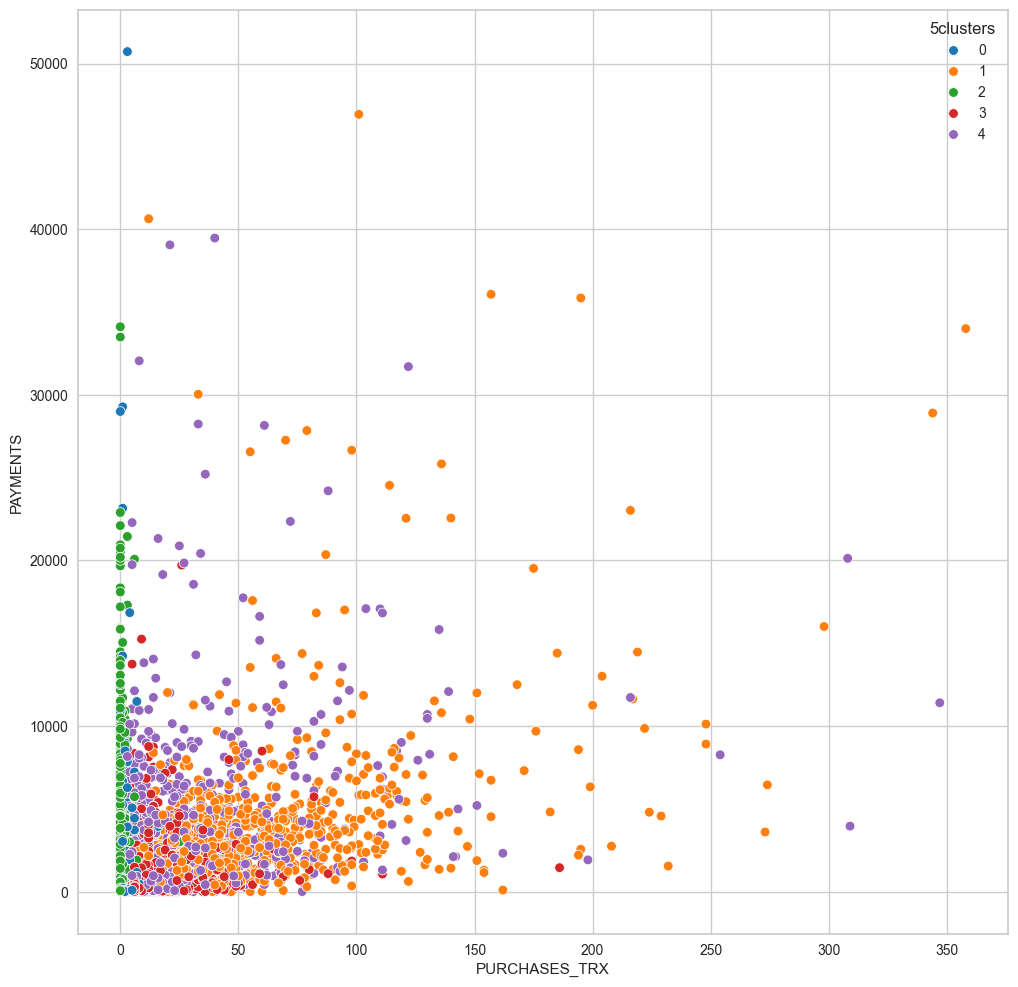

In [37]:
# 5 clusters
plt.figure(figsize=(12,12))
seaborn.scatterplot(data= data2, y=('PAYMENTS'),x=('PURCHASES_TRX'), hue='5clusters',palette='tab10')
plt.show()

# Results #

The elbow method identified five clusters as the optimal solution, so I further evaluated clustering results with four to eight clusters to assess the stability and quality of the segmentation. This comparison provided additional context for selecting the final clustering model and interpreting customer behavior patterns.

Model evaluation revealed a trade-off between cluster cohesion and cluster separation. The four-cluster solution achieved the highest silhouette score (0.472), indicating the strongest separation between clusters, while the eight-cluster solution produced the lowest inertia value (855.611), reflecting tighter groupings within clusters. As the number of clusters increased, inertia consistently decreased, while silhouette scores generally declined. The five-cluster solution, selected by the elbow method, produced a silhouette score of 0.447 and an inertia value of 1439.892, representing a reasonable balance between cluster compactness and interpretability. Although the four-cluster model achieved a slightly higher silhouette score, the five-cluster solution provided greater segmentation detail while maintaining comparable clustering quality.

The elbow method suggested using 5 clusters, while the silhouette score indicated that 4 clusters produced better cluster separation. Since both results appeared reasonable, I compared the clustering results and chose to continue my analysis using 5 clusters because it provided a more details of customer behaviors.

Using the five-cluster solution, I identified several distinct customer spending behaviors. Customers in Cluster 2 exhibited the highest levels of overall spending, single purchase transactions, and installment purchases, suggesting a group of highly active credit card users. Cluster 1 also showed elevated spending activity but was characterized by a greater reliance on cash advances. In contrast, Clusters 3 and 4 demonstrated relatively low spending activity, infrequent cash advances, and fewer single purchase transactions, indicating more conservative credit card usage patterns.

One notable finding was the relationship between purchase behavior and payment methods. Higher levels of single purchase transactions were generally associated with higher overall spending, particularly among customers in Clusters 1 and 2. Cluster 0 represented a unique segment that exhibited high cash advance activity despite relatively low purchase activity, suggesting a different use case for credit card services.

Comparing the five-cluster solution to the four-cluster alternative revealed similar overall patterns, although the four-cluster model produced a slightly higher silhouette score. While the elbow method indicated that five clusters provided an appropriate balance between model complexity and within-cluster variation, the comparison highlighted the importance of evaluating clustering results using multiple metrics rather than relying on a single factor.


# Conclusions #

This project demonstrated the complete workflow of applying K-Means clustering to real-world customer behavior data. After addressing missing values, transforming and scaling the features, and reducing dimensionality with PCA, I evaluated multiple clustering solutions using the elbow method, silhouette scores, and inertia metrics. Although the elbow method suggested five clusters, comparing alternative cluster counts highlighted the tradeoffs between cluster separation and model complexity.

The final clustering results revealed distinct customer spending and payment behaviors, including differences in purchase frequency, cash advance usage, installment purchases, and overall spending activity. Beyond the clustering results themselves, this project provided valuable experience in data preparation, dimensionality reduction, cluster evaluation, and interpreting unsupervised learning outputs. It also demonstrated how clustering techniques can be used to uncover meaningful customer segments and generate business insights from unlabeled data.

# References #


Amelia, Azika. “K-Means Clustering: From A to Z.” Medium, Towards Data Science, 28 Sept. 2018, https://towardsdatascience.com/k-means-clustering-from-a-to-z-f6242a314e9a. 

<span id="fn1"> Varia, Mayank. DS121: Foundations of Data Science II. 13 Sep. 2022, Boston University, Boston. Class lecture.</span>

<span id="fn2"> Varia, Mayank. DS121: Foundations of Data Science II. 13 Sep. 2022, Boston University, Boston. Class lecture </span>

<span id="fn3"> Sagar, Abhinav. “Customer Segmentation Using K Means Clustering.” Medium, Towards Data Science, 3 Dec. 2019, https://towardsdatascience.com/customer-segmentation-using-k-means-clustering-d33964f238c3. </span>

<span id="fn4">  Bhasin, Arjun. “Credit Card Dataset for Clustering.” Kaggle, 2 Mar. 2018, https://www.kaggle.com/datasets/arjunbhasin2013/ccdata. </span>

<span id="fn5"> Brownlee, Jason. “How to Use Power Transforms for Machine Learning.” MachineLearningMastery.com, 27 Aug. 2020, https://machinelearningmastery.com/power-transforms-with-scikit-learn/. </span>

<span id="fn6"> “Elbow Method.” Elbow Method - Yellowbrick v1.5 Documentation, https://www.scikit-yb.org/en/latest/api/cluster/elbow.html.</span>

<span id="fn7">"Solution_HW9." DS121: Foundations of Data Science II, Boston University, 2022.</span>

<span id="fn8"> "Solution_HW9." DS121: Foundations of Data Science II, Boston University, 2022.</span>

<span id="fn9"> "Solution_HW9." DS121: Foundations of Data Science II, Boston University, 2022.</span>

<span id="fn10"> "Solution_HW9." DS121: Foundations of Data Science II, Boston University, 2022.</span>

<span id="fn11"> "Solution_HW9." DS121: Foundations of Data Science II, Boston University, 2022.</span>

<span id="fn12"> "Solution_HW9." DS121: Foundations of Data Science II, Boston University, 2022.</span>

